# UAE Zero-Shot Evaluation — Step 4

Evaluates all 6 trained 250 K-step policies on real Dubai summer climate
(**no retraining**).  Weather source: EnergyPlus TMYx 2007-2021, Dubai
International Airport, June–August (peak heat season).

| Climate | Temp mean | Temp max | Season |
|---------|-----------|----------|--------|
| US training | 28.0 °C | 38.1 °C | Mixed year |
| Dubai eval  | 36.0 °C | 47.0 °C | Jun–Aug |

Outputs:
- UAE KPIs for all 6 conditions + neutral baseline
- **Degradation rates** (UAE vs US) per KPI per condition
- US vs UAE comparison plots
- All tables saved to `results_uae/`


In [1]:
from __future__ import annotations
import json, math, random, shutil, sys, warnings
from pathlib import Path
from typing import Dict, List, Mapping, Optional, Tuple

warnings.filterwarnings("ignore")

import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from citylearn.citylearn import CityLearnEnv
from citylearn.data import DataSet
from citylearn.reward_function import RewardFunction
from IPython.display import display, Image
from torch.distributions import Normal

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEFAULT_DATASET = "citylearn_challenge_2023_phase_3_1"
ALL_CONDITIONS = [
    ("ippo",  "flat_shared"),
    ("ippo",  "local_individual"),
    ("ippo",  "uae_weighted"),
    ("mappo", "flat_shared"),
    ("mappo", "local_individual"),
    ("mappo", "uae_weighted"),
]
KPI_NAMES = ["cost_total", "carbon_emissions_total",
             "discomfort_proportion", "ramping_average",
             "daily_one_minus_load_factor_average"]

Path("results_uae").mkdir(exist_ok=True)
print("device:", DEVICE)
print("conditions:", len(ALL_CONDITIONS))


device: cpu
conditions: 6


## 1 · Create Dubai Climate Schema

Copies the full CityLearn 2023 dataset (building loads, LSTM dynamics, pricing,
carbon) and replaces only `weather.csv` with real Dubai TMYx summer data.


In [2]:
DUBAI_WEATHER_SRC = Path("dubai_weather.csv")
UAE_DATASET_DIR   = Path("citylearn_uae_dubai")
US_CACHE = Path.home() / "Library/Caches/citylearn/v2.5.0/datasets" / DEFAULT_DATASET

def create_uae_schema():
    if UAE_DATASET_DIR.exists():
        shutil.rmtree(UAE_DATASET_DIR)
    shutil.copytree(US_CACHE, UAE_DATASET_DIR)
    shutil.copy2(DUBAI_WEATHER_SRC, UAE_DATASET_DIR / "weather.csv")

    # Load and return the schema dict with updated root_directory
    schema_path = UAE_DATASET_DIR / "schema.json"
    with open(schema_path) as f:
        schema = json.load(f)
    schema["root_directory"] = str(UAE_DATASET_DIR.resolve())
    with open(schema_path, "w") as f:
        json.dump(schema, f)
    print(f"UAE schema created at {UAE_DATASET_DIR}/")
    return str(schema_path)

UAE_SCHEMA_PATH = create_uae_schema()

# Quick sanity check — compare weather stats
us_w  = pd.read_csv(US_CACHE / "weather.csv")
uae_w = pd.read_csv(UAE_DATASET_DIR / "weather.csv")
print(f"US  mean temp: {us_w['outdoor_dry_bulb_temperature'].mean():.1f} °C  "
      f"max: {us_w['outdoor_dry_bulb_temperature'].max():.1f} °C")
print(f"UAE mean temp: {uae_w['outdoor_dry_bulb_temperature'].mean():.1f} °C  "
      f"max: {uae_w['outdoor_dry_bulb_temperature'].max():.1f} °C")


UAE schema created at citylearn_uae_dubai/
US  mean temp: 28.0 °C  max: 38.1 °C
UAE mean temp: 36.0 °C  max: 47.0 °C


In [3]:
DEFAULT_FLAT_WEIGHTS = {"discomfort":0.10,"electricity":0.10,"ramping":0.10,"solar":0.10}
UAE_WEIGHTED_WEIGHTS = {"discomfort":0.140,"electricity":0.120,"ramping":0.060,"solar":0.080}

class ProjectReward(RewardFunction):
    def __init__(self, env_metadata=None, weights=None, shared=True, **_):
        super().__init__(env_metadata)
        self.weights = dict(DEFAULT_FLAT_WEIGHTS if weights is None else weights)
        self.shared  = shared
        self.prev_de = None; self.prev_le = None

    def calculate(self, observations):
        comps = [self._c(o) for o in observations]
        de = float(sum(c["electricity"] for c in comps))
        dr = 0. if self.prev_de is None else abs(de - self.prev_de)
        self.prev_de = de
        le = [c["electricity"] for c in comps]
        lr = ([0.]*len(le) if self.prev_le is None
              else [abs(a-b) for a,b in zip(le, self.prev_le)])
        self.prev_le = le
        if self.shared:
            dc = {"discomfort":float(sum(c["discomfort"] for c in comps)),
                  "electricity":de,"ramping":dr,
                  "solar":float(sum(c["solar"] for c in comps))}
            r = -self._w(dc); return [r]*len(observations)
        return [-self._w({**c,"ramping":lr[i]}) for i,c in enumerate(comps)]

    def reset_memory(self): self.prev_de=None; self.prev_le=None

    def _c(self, o):
        net=float(o.get("net_electricity_consumption",0.)); imp=max(net,0.)
        sol=max(float(o.get("solar_generation",0.)),0.)
        return {"discomfort":self._d(o),"electricity":imp,"ramping":0.,
                "solar":imp if sol>0. else 0.}

    def _d(self, o):
        if "average_unmet_cooling_setpoint_difference" in o:
            return max(float(o["average_unmet_cooling_setpoint_difference"]),0.)
        if "indoor_dry_bulb_temperature_delta" in o:
            return abs(float(o["indoor_dry_bulb_temperature_delta"]))
        t=float(o.get("indoor_dry_bulb_temperature",0.))
        return abs(t-float(o.get("indoor_dry_bulb_temperature_set_point",t)))

    def _w(self, c): return float(sum(self.weights[k]*c[k] for k in self.weights))

class FlatSharedReward(ProjectReward):
    def __init__(self,e=None,**kw): super().__init__(e,DEFAULT_FLAT_WEIGHTS,True,**kw)
class LocalIndividualReward(ProjectReward):
    def __init__(self,e=None,**kw): super().__init__(e,DEFAULT_FLAT_WEIGHTS,False,**kw)
class UAEWeightedSharedReward(ProjectReward):
    def __init__(self,e=None,**kw): super().__init__(e,UAE_WEIGHTED_WEIGHTS,True,**kw)

REWARD_FUNCTIONS = {
    "flat_shared":FlatSharedReward,
    "local_individual":LocalIndividualReward,
    "uae_weighted":UAEWeightedSharedReward,
}
print("Reward functions ready.")


Reward functions ready.


In [4]:
def _box(sp): return gym.spaces.Box(np.asarray(sp.low,np.float32),np.asarray(sp.high,np.float32),sp.shape,np.float32)
def _neu(sp): return np.clip(np.zeros(sp.shape,np.float32),sp.low,sp.high)

class MARLEnv:
    def __init__(self, schema, reward_mode="flat_shared", seed=None, safety=0.75):
        self.safety=safety
        self.base=CityLearnEnv(schema,reward_function=REWARD_FUNCTIONS[reward_mode],
                               central_agent=False,random_seed=seed)
        self.agents=[b.name for b in self.base.buildings]
        self.nas={a:_box(sp) for a,sp in zip(self.agents,self.base.action_space)}
        self.obs_spaces={a:_box(sp) for a,sp in zip(self.agents,self.base.observation_space)}
        self.act_spaces={a:gym.spaces.Box(-1.,1.,sp.shape,np.float32) for a,sp in self.nas.items()}
        self._obs=None

    def reset(self,seed=None):
        if seed: np.random.seed(seed)
        r=self.base.reset(); obs,info=(r if isinstance(r,tuple) and len(r)==2 else (r,{}))
        if hasattr(self.base.reward_function,"reset_memory"): self.base.reward_function.reset_memory()
        self._obs=self._fo(obs); return self._obs,{a:{} for a in self.agents}

    def step(self,actions):
        acts=[];
        for a in self.agents:
            ac=np.clip(np.asarray(actions[a],np.float32).reshape(-1),-1.,1.)
            ns=self.nas[a]; neu=_neu(ns)
            ac=neu+self.safety*np.where(ac>=0,ac*(ns.high-neu),ac*(neu-ns.low))
            acts.append(np.clip(ac,ns.low,ns.high).astype(np.float32))
        try: r=self.base.step(acts)
        except: r=self.base.step([_neu(self.nas[a]) for a in self.agents])
        obs,rws,term,trunc,info=(r if len(r)==5 else (*r[:2],bool(r[2]),False,r[3]))
        self._obs=self._fo(obs)
        rwd={a:float(v) for a,v in zip(self.agents,rws if len(rws)>1 else rws*len(self.agents))}
        return self._obs,rwd,{a:bool(term) for a in self.agents},{a:bool(trunc) for a in self.agents},{}

    def kpis(self):
        df=pd.DataFrame(self.base.evaluate())
        if {"level","cost_function","value"}.issubset(df.columns):
            d=df[df["level"]=="district"]
            return d[d["cost_function"].isin(KPI_NAMES)][["cost_function","value"]].reset_index(drop=True)
        return df

    def close(self):
        fn=getattr(self.base,"close",None)
        if callable(fn): fn()

    def _fo(self,obs):
        return {a:np.asarray(list(o.values()) if isinstance(o,Mapping) else o,np.float32).reshape(-1)
                for a,o in zip(self.agents,obs)}

print("Environment wrapper ready.")


Environment wrapper ready.


In [5]:
def layer_init(l,std=math.sqrt(2),b=0.):
    nn.init.orthogonal_(l.weight,std); nn.init.constant_(l.bias,b); return l

def mlp(i,o,h,os=1.):
    return nn.Sequential(layer_init(nn.Linear(i,h)),nn.Tanh(),
                         layer_init(nn.Linear(h,h)),nn.Tanh(),
                         layer_init(nn.Linear(h,o),std=os))

class RunningNormalize:
    def __init__(self,shape,eps=1e-8,clip=10.):
        self.mean=np.zeros(shape,np.float64); self.var=np.ones(shape,np.float64)
        self.count=0; self.eps=eps; self.clip=clip
    def normalize(self,x):
        return np.clip((x-self.mean)/np.sqrt(self.var+self.eps),-self.clip,self.clip).astype(np.float32)

class SquashedGaussianActor(nn.Module):
    def __init__(self,od,ad,h):
        super().__init__(); self.mean_net=mlp(od,ad,h,0.01); self.log_std=nn.Parameter(torch.zeros(ad))
    def deterministic(self,o): return torch.tanh(self.mean_net(o))

class IPPOActorCritic(nn.Module):
    def __init__(self,od,ad,h):
        super().__init__(); self.actor=SquashedGaussianActor(od,ad,h); self.critic=mlp(od,1,h)

class CentralCritic(nn.Module):
    def __init__(self,sd,h): super().__init__(); self.net=mlp(sd,1,h)
    def forward(self,s): return self.net(s).squeeze(-1)

def to_t(x): return torch.as_tensor(x,dtype=torch.float32,device=DEVICE)

print("Models defined.")


Models defined.


## 2 · Load All 250 K Trained Models


In [6]:
# Discover env dims from a temp env
_env = MARLEnv(UAE_SCHEMA_PATH, seed=42)
_obs,_=_env.reset(seed=42)
AGENTS   = _env.agents
OBS_DIM  = _obs[AGENTS[0]].shape[0]
ACT_DIM  = _env.act_spaces[AGENTS[0]].shape[0]
STATE_DIM= np.concatenate([_obs[a] for a in AGENTS]).shape[0]
_env.close()

HIDDEN = 256
loaded = {}

for algo, reward_mode in ALL_CONDITIONS:
    cp = Path("models") / f"{algo}_{reward_mode}_250k.pt"
    ck = torch.load(cp, map_location=DEVICE, weights_only=False)

    norms = {a:RunningNormalize(OBS_DIM) for a in AGENTS}
    for a in AGENTS:
        norms[a].mean  = ck["norm_means"][a]
        norms[a].var   = ck["norm_vars"][a]
        norms[a].count = 250_000

    if algo == "ippo":
        policies = nn.ModuleDict({a:IPPOActorCritic(OBS_DIM,ACT_DIM,HIDDEN).to(DEVICE) for a in AGENTS})
        policies.load_state_dict(ck["state_dict"])
        policies.eval()
        loaded[(algo,reward_mode)] = {"type":"ippo","policies":policies,"norms":norms}
    else:
        actors = nn.ModuleDict({a:SquashedGaussianActor(OBS_DIM,ACT_DIM,HIDDEN).to(DEVICE) for a in AGENTS})
        critic = CentralCritic(STATE_DIM,HIDDEN).to(DEVICE)
        actors.load_state_dict(ck["actor_state_dict"])
        critic.load_state_dict(ck["critic_state_dict"])
        actors.eval(); critic.eval()
        loaded[(algo,reward_mode)] = {"type":"mappo","actors":actors,"norms":norms}
    print(f"  loaded  {cp.name}")

print(f"\nAll {len(loaded)} models ready.")
print(f"agents={len(AGENTS)}  obs_dim={OBS_DIM}  act_dim={ACT_DIM}")


  loaded  ippo_flat_shared_250k.pt
  loaded  ippo_local_individual_250k.pt
  loaded  ippo_uae_weighted_250k.pt
  loaded  mappo_flat_shared_250k.pt
  loaded  mappo_local_individual_250k.pt
  loaded  mappo_uae_weighted_250k.pt

All 6 models ready.
agents=6  obs_dim=30  act_dim=3


## 3 · UAE Evaluation

Each policy runs on the Dubai summer climate without any retraining.
The normalizer statistics from US training are kept as-is — this is
intentional: it tests whether the normalizer (trained on US temperature
distributions) causes degradation when applied to out-of-distribution
UAE temperatures.


In [7]:
@torch.no_grad()
def get_actions(algo, reward_mode, obs):
    m = loaded[(algo, reward_mode)]
    norms = m["norms"]
    if m["type"] == "ippo":
        return {a: m["policies"][a].actor.deterministic(
                    to_t(norms[a].normalize(obs[a])).unsqueeze(0)
                   ).squeeze(0).cpu().numpy().astype(np.float32)
                for a in AGENTS}
    return {a: m["actors"][a].deterministic(
                to_t(norms[a].normalize(obs[a])).unsqueeze(0)
               ).squeeze(0).cpu().numpy().astype(np.float32)
            for a in AGENTS}


def run_eval(algo, reward_mode, schema, seed=142, max_steps=8760):
    env_reward_mode = "flat_shared" if algo == "neutral" else reward_mode
    env = MARLEnv(schema, reward_mode=env_reward_mode, seed=seed)
    obs,_=env.reset(seed=seed)
    cum={a:0. for a in AGENTS}
    for step in range(1,max_steps+1):
        if algo == "neutral":
            acts={a:np.zeros(env.act_spaces[a].shape,np.float32) for a in AGENTS}
        else:
            acts=get_actions(algo,reward_mode,obs)
        obs,rws,tms,trs,_=env.step(acts)
        for a,r in rws.items(): cum[a]+=float(r)
        if any(tms.values()) or any(trs.values()): break
    mean=float(np.mean(list(cum.values())))
    try:
        kpis=env.kpis(); kpis.insert(0,"reward_mode",reward_mode if algo!="neutral" else "neutral")
        kpis.insert(0,"algorithm",algo)
    except Exception as e:
        kpis=pd.DataFrame({"algorithm":[algo],"reward_mode":[reward_mode],"error":[str(e)]})
    env.close()
    row={"algorithm":algo,"reward_mode":reward_mode if algo!="neutral" else "neutral",
         "steps":step,"mean_agent_reward":mean,**cum}
    return pd.DataFrame([row]),kpis


print("Evaluation function defined.")
print("Running UAE evaluation for all 7 conditions (6 + neutral)...")


Evaluation function defined.
Running UAE evaluation for all 7 conditions (6 + neutral)...


In [8]:
uae_rewards_list, uae_kpis_list = [], []

print("Neutral baseline...")
rr,rk = run_eval("neutral","neutral",UAE_SCHEMA_PATH)
uae_rewards_list.append(rr); uae_kpis_list.append(rk)
print(f"  reward={rr['mean_agent_reward'].iloc[0]:.2f}")

for algo, reward_mode in ALL_CONDITIONS:
    print(f"{algo} | {reward_mode} ...")
    rr,rk = run_eval(algo,reward_mode,UAE_SCHEMA_PATH)
    uae_rewards_list.append(rr); uae_kpis_list.append(rk)
    print(f"  reward={rr['mean_agent_reward'].iloc[0]:.2f}")

uae_rewards = pd.concat(uae_rewards_list, ignore_index=True)
uae_kpis    = pd.concat(uae_kpis_list,    ignore_index=True)

uae_rewards.to_csv("results_uae/uae_rewards.csv", index=False)
uae_kpis.to_csv("results_uae/uae_kpis.csv",       index=False)

print("\n=== UAE Evaluation Reward Summary ===")
display(uae_rewards[["algorithm","reward_mode","mean_agent_reward"]].sort_values(
    "mean_agent_reward", ascending=False))


Neutral baseline...


  reward=-1425.18
ippo | flat_shared ...


  reward=-1550.14
ippo | local_individual ...


  reward=-263.93
ippo | uae_weighted ...


  reward=-1480.70
mappo | flat_shared ...


  reward=-1706.01
mappo | local_individual ...


  reward=-311.39
mappo | uae_weighted ...


  reward=-1529.67

=== UAE Evaluation Reward Summary ===


,algorithm,reward_mode,mean_agent_reward
2,ippo,local_individual,-263.932025
5,mappo,local_individual,-311.387510
0,neutral,neutral,-1425.179576
3,ippo,uae_weighted,-1480.701490
6,mappo,uae_weighted,-1529.671473
1,ippo,flat_shared,-1550.138856
4,mappo,flat_shared,-1706.011229


## 4 · Degradation Rates (US → UAE)

**Degradation rate** = `(UAE_KPI - US_KPI) / US_KPI × 100`

Positive = KPI got worse under UAE climate.
Negative = KPI improved (unexpected benefit from the climate shift).


In [9]:
us_kpis = pd.read_csv("results_250k/summary/all_kpis.csv")

# Build degradation table
rows = []
for (algo, rm), grp in uae_kpis[uae_kpis["algorithm"]!="neutral"].groupby(["algorithm","reward_mode"]):
    row = {"algorithm":algo, "reward_mode":rm}
    us_grp = us_kpis[(us_kpis["algorithm"]==algo) & (us_kpis["reward_mode"]==rm)]
    for kpi in KPI_NAMES:
        uae_val = grp[grp["cost_function"]==kpi]["value"]
        us_val  = us_grp[us_grp["cost_function"]==kpi]["value"]
        if len(uae_val) and len(us_val):
            u = float(uae_val.iloc[0]); s = float(us_val.iloc[0])
            row[f"{kpi}_US"]  = round(s, 4)
            row[f"{kpi}_UAE"] = round(u, 4)
            row[f"{kpi}_degradation_pct"] = round((u-s)/abs(s)*100, 2) if s else None
    rows.append(row)

degradation_df = pd.DataFrame(rows)
degradation_df.to_csv("results_uae/degradation_rates.csv", index=False)

# Clean display
deg_cols = ["algorithm","reward_mode"] + [c for c in degradation_df.columns if "degradation" in c]
print("=== KPI Degradation Rates US → UAE (positive = worse in UAE) ===")
display(degradation_df[deg_cols].to_string(index=False))


=== KPI Degradation Rates US → UAE (positive = worse in UAE) ===


'algorithm      reward_mode  cost_total_degradation_pct  carbon_emissions_total_degradation_pct  discomfort_proportion_degradation_pct  ramping_average_degradation_pct  daily_one_minus_load_factor_average_degradation_pct\n     ippo      flat_shared                      -18.87                                  -18.51                                   5.31                           -11.49                                                 3.86\n     ippo local_individual                      -16.70                                  -17.16                                   2.40                            -7.76                                                 5.88\n     ippo     uae_weighted                      -18.04                                  -16.82                                   3.74                            -9.32                                                 4.98\n    mappo      flat_shared                       -0.20                                   -1.04                     

In [10]:
# Pivot: rows = condition, cols = KPI, sub-cols = US / UAE
all_kpi_rows = []
for (algo,rm), grp in uae_kpis.groupby(["algorithm","reward_mode"]):
    for kpi in KPI_NAMES:
        v = grp[grp["cost_function"]==kpi]["value"]
        if len(v):
            all_kpi_rows.append({"algorithm":algo,"reward_mode":rm,
                                  "kpi":kpi,"climate":"UAE","value":float(v.iloc[0])})

for (algo,rm), grp in us_kpis.groupby(["algorithm","reward_mode"]):
    for kpi in KPI_NAMES:
        v = grp[grp["cost_function"]==kpi]["value"]
        if len(v):
            all_kpi_rows.append({"algorithm":algo,"reward_mode":rm,
                                  "kpi":kpi,"climate":"US","value":float(v.iloc[0])})

all_kpi_df = pd.DataFrame(all_kpi_rows)
pivot = all_kpi_df.pivot_table(index=["algorithm","reward_mode"],
                                columns=["kpi","climate"], values="value").round(4)
pivot.to_csv("results_uae/us_vs_uae_kpi_pivot.csv")
print("=== US vs UAE KPI Pivot Table ===")
display(pivot)


=== US vs UAE KPI Pivot Table ===


kpi                        carbon_emissions_total         cost_total          \
climate                                       UAE      US        UAE      US   
algorithm reward_mode                                                          
ippo      flat_shared                      0.4140  0.5080     0.3948  0.4866   
          local_individual                 0.3717  0.4487     0.3466  0.4161   
          uae_weighted                     0.4134  0.4970     0.3922  0.4785   
mappo     flat_shared                      0.4819  0.4870     0.4549  0.4558   
          local_individual                 0.4371  0.4607     0.4051  0.4310   
          uae_weighted                     0.4315  0.4563     0.4086  0.4304   
neutral   neutral                          0.3616  0.4300     0.3392  0.4024   

kpi                        daily_one_minus_load_factor_average          \
climate                                                    UAE      US   
algorithm reward_mode                                                    
ippo      flat_shared                                   1.3959  1.3440   
          local_individual                              1.4009  1.3230   
          uae_weighted                                  1.4024  1.3359   
mappo     flat_shared                                   1.2748  1.3245   
          local_individual                              1.3279  1.3380   
          uae_weighted                                  1.3254  1.3246   
neutral   neutral                                       1.4469  1.3722   

kpi                        discomfort_proportion         ramping_average  \
climate                                      UAE      US             UAE   
algorithm reward_mode                                                      
ippo      flat_shared                     0.9933  0.9433          0.8766   
          local_individual                0.9942  0.9710          0.7854   
          uae_weighted                    0.9929  0.9571          0.8918   
mappo     flat_shared                     0.9863  0.9636          0.8025   
          local_individual                0.9884  0.9719          0.8236   
          uae_weighted                    0.9937  0.9697          0.8385   
neutral   neutral                         0.9942  0.9727          0.8187   

kpi                                 
climate                         US  
algorithm reward_mode               
ippo      flat_shared       0.9903  
          local_individual  0.8514  
          uae_weighted      0.9835  
mappo     flat_shared       0.9708  
          local_individual  0.9068  
          uae_weighted      0.9240  
neutral   neutral           0.8734

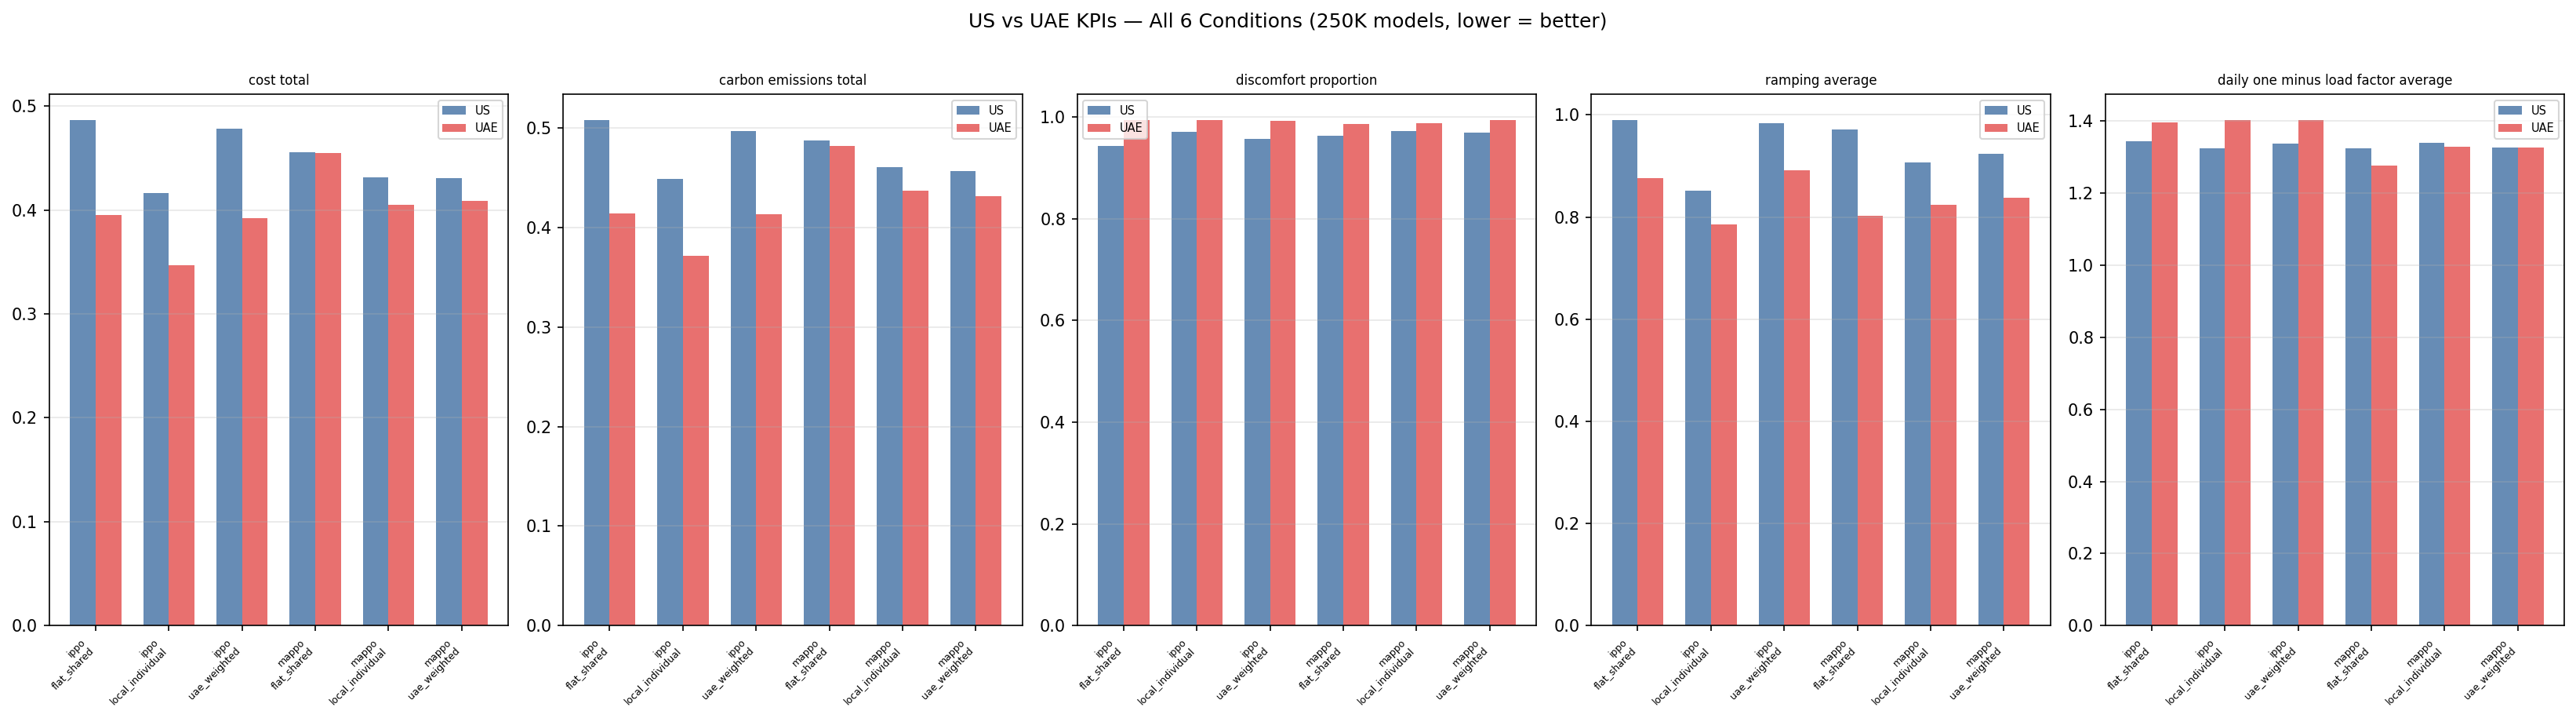

In [11]:
fig, axes = plt.subplots(1, len(KPI_NAMES), figsize=(22, 6))
x = np.arange(len(ALL_CONDITIONS))
w = 0.35
labels = [f"{a}\n{r}" for a,r in ALL_CONDITIONS]

for ax, kpi in zip(axes, KPI_NAMES):
    us_vals, uae_vals = [], []
    for algo, rm in ALL_CONDITIONS:
        u = us_kpis[(us_kpis["algorithm"]==algo)&(us_kpis["reward_mode"]==rm)&
                    (us_kpis["cost_function"]==kpi)]["value"]
        a = uae_kpis[(uae_kpis["algorithm"]==algo)&(uae_kpis["reward_mode"]==rm)&
                     (uae_kpis["cost_function"]==kpi)]["value"]
        us_vals.append(float(u.iloc[0]) if len(u) else 0)
        uae_vals.append(float(a.iloc[0]) if len(a) else 0)

    ax.bar(x - w/2, us_vals,  w, label="US",  color="#4C78A8", alpha=0.85)
    ax.bar(x + w/2, uae_vals, w, label="UAE", color="#E45756", alpha=0.85)
    ax.set_title(kpi.replace("_"," "), fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=7)

plt.suptitle("US vs UAE KPIs — All 6 Conditions (250K models, lower = better)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("results_uae/us_vs_uae_kpi_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_uae/us_vs_uae_kpi_comparison.png"))


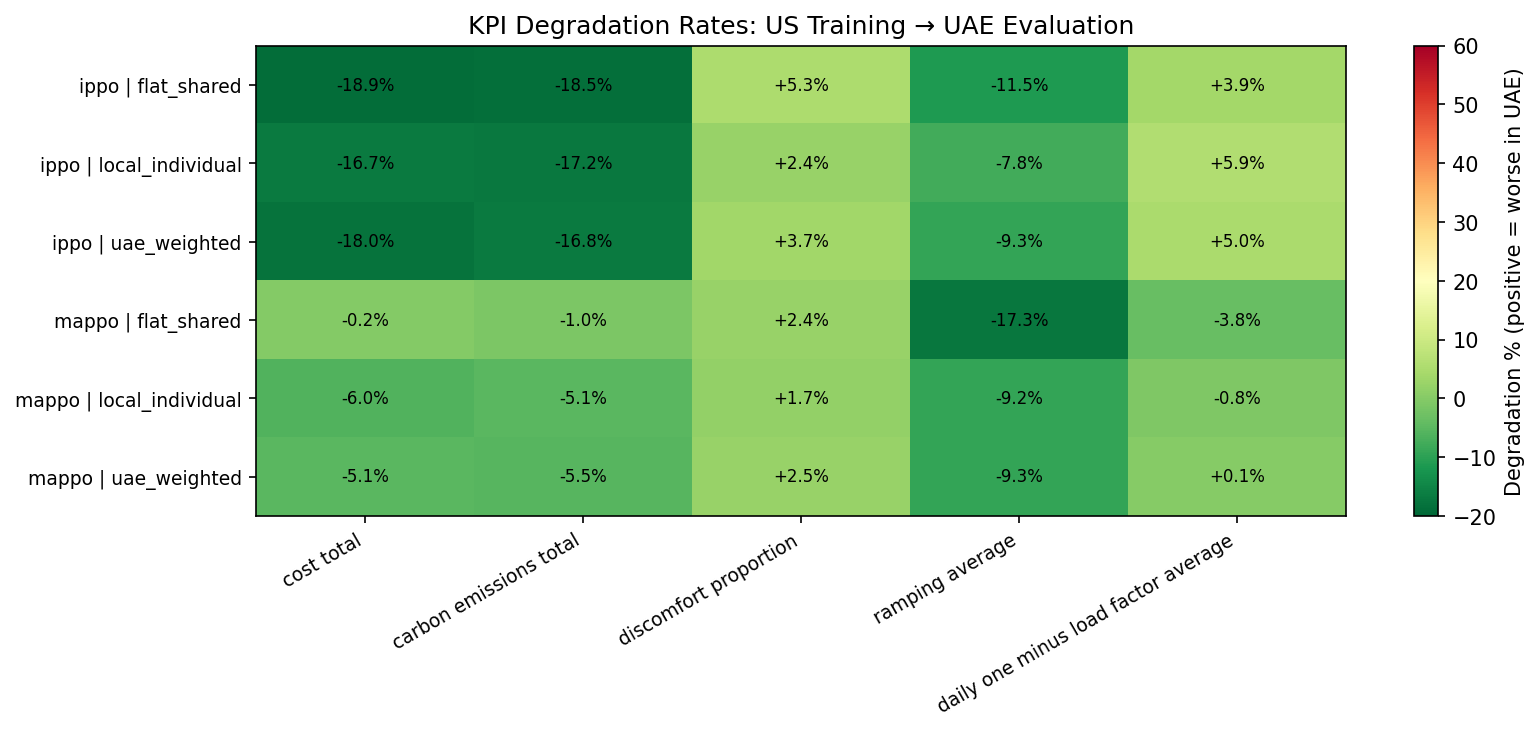

In [12]:
deg_pivot = degradation_df.set_index(["algorithm","reward_mode"])[
    [c for c in degradation_df.columns if "degradation" in c]
].rename(columns=lambda c: c.replace("_degradation_pct","").replace("_"," "))

fig2, ax2 = plt.subplots(figsize=(11, 5))
im = ax2.imshow(deg_pivot.values.astype(float), cmap="RdYlGn_r", aspect="auto",
                vmin=-20, vmax=60)
ax2.set_xticks(range(len(deg_pivot.columns)))
ax2.set_xticklabels(deg_pivot.columns, fontsize=9, rotation=30, ha="right")
ax2.set_yticks(range(len(deg_pivot.index)))
ax2.set_yticklabels([f"{a} | {r}" for a,r in deg_pivot.index], fontsize=9)
for i in range(len(deg_pivot.index)):
    for j in range(len(deg_pivot.columns)):
        val = deg_pivot.values[i,j]
        if val is not None:
            ax2.text(j, i, f"{float(val):+.1f}%", ha="center", va="center",
                     fontsize=8, color="black")
plt.colorbar(im, ax=ax2, label="Degradation % (positive = worse in UAE)")
ax2.set_title("KPI Degradation Rates: US Training → UAE Evaluation", fontsize=12)
plt.tight_layout()
plt.savefig("results_uae/degradation_heatmap.png", dpi=150, bbox_inches="tight")
plt.close(fig2)
display(Image("results_uae/degradation_heatmap.png"))


In [13]:
print("=== UAE Reward Ranking (higher = better) ===")
display(uae_rewards[["algorithm","reward_mode","mean_agent_reward"]]
        .sort_values("mean_agent_reward", ascending=False).reset_index(drop=True))

print()
print("=== Least-degraded condition per KPI ===")
for kpi in KPI_NAMES:
    col = f"{kpi}_degradation_pct"
    if col in degradation_df.columns:
        best = degradation_df.loc[degradation_df[col].idxmin()]
        print(f"  {kpi:<45} -> {best['algorithm']} | {best['reward_mode']}  "
              f"({best[col]:+.2f}%)")

print()
print("=== Most-degraded condition per KPI ===")
for kpi in KPI_NAMES:
    col = f"{kpi}_degradation_pct"
    if col in degradation_df.columns:
        worst = degradation_df.loc[degradation_df[col].idxmax()]
        print(f"  {kpi:<45} -> {worst['algorithm']} | {worst['reward_mode']}  "
              f"({worst[col]:+.2f}%)")


=== UAE Reward Ranking (higher = better) ===


,algorithm,reward_mode,mean_agent_reward
0,ippo,local_individual,-263.932025
1,mappo,local_individual,-311.387510
2,neutral,neutral,-1425.179576
3,ippo,uae_weighted,-1480.701490
4,mappo,uae_weighted,-1529.671473
5,ippo,flat_shared,-1550.138856
6,mappo,flat_shared,-1706.011229



=== Least-degraded condition per KPI ===
  cost_total                                    -> ippo | flat_shared  (-18.87%)
  carbon_emissions_total                        -> ippo | flat_shared  (-18.51%)
  discomfort_proportion                         -> mappo | local_individual  (+1.70%)
  ramping_average                               -> mappo | flat_shared  (-17.34%)
  daily_one_minus_load_factor_average           -> mappo | flat_shared  (-3.75%)

=== Most-degraded condition per KPI ===
  cost_total                                    -> mappo | flat_shared  (-0.20%)
  carbon_emissions_total                        -> mappo | flat_shared  (-1.04%)
  discomfort_proportion                         -> ippo | flat_shared  (+5.31%)
  ramping_average                               -> ippo | local_individual  (-7.76%)
  daily_one_minus_load_factor_average           -> ippo | local_individual  (+5.88%)


## Output Files

```
results_uae/
  uae_rewards.csv                ← reward per condition in UAE
  uae_kpis.csv                   ← raw KPIs per condition in UAE
  degradation_rates.csv          ← US vs UAE per KPI (report table)
  us_vs_uae_kpi_pivot.csv        ← full US/UAE pivot for report
  us_vs_uae_kpi_comparison.png   ← grouped bar chart figure
  degradation_heatmap.png        ← heatmap figure (report-ready)

citylearn_uae_dubai/             ← UAE dataset (CityLearn + Dubai weather)
  weather.csv                    ← real TMYx Dubai Jun–Aug data
```

**Next step:** Step 5 analysis notebook — Reward Transfer Score, seasonal
breakdown (months within Jun–Aug), Pareto cost/discomfort frontier shift.
